In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Load dataset
file_path = "insurance.csv"
df = pd.read_csv(file_path)

In [5]:
# Display first few rows to check dataset structure
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [6]:
# Display dataset summary statistics
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [7]:
# Check the data types of each column
print(df.dtypes)


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [8]:
# Check for missing values
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


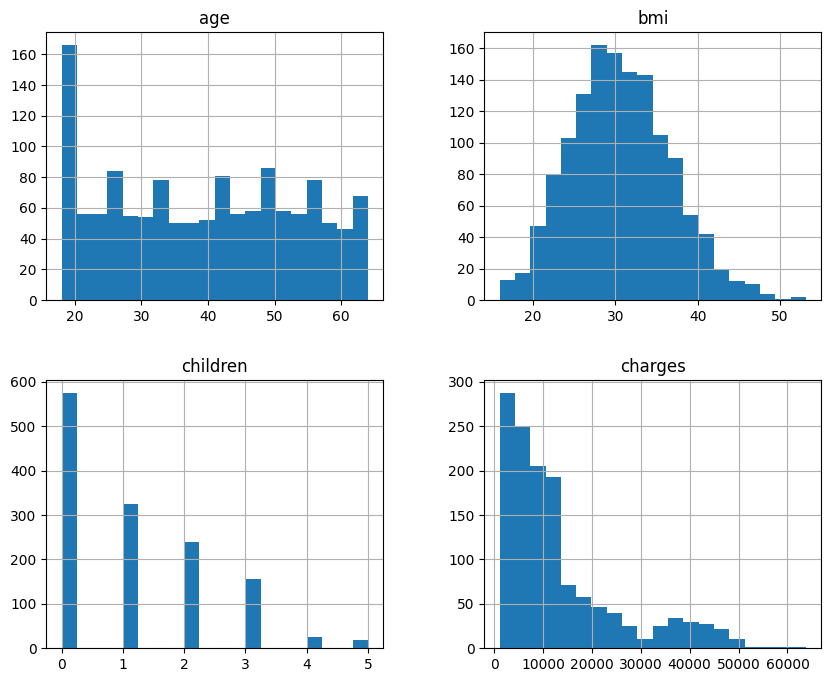

In [9]:
# Graphical representation of data
df.hist(figsize=(10, 8), bins=20)
plt.show()

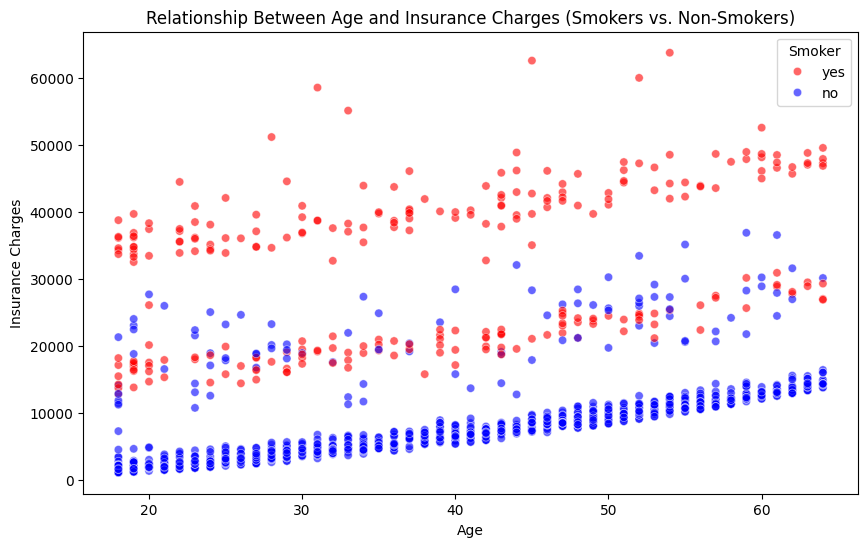

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['age'], y=df['charges'], hue=df['smoker'], alpha=0.6, palette={'yes': 'red', 'no': 'blue'})
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Relationship Between Age and Insurance Charges (Smokers vs. Non-Smokers)")
plt.legend(title="Smoker")
plt.show()


C:\Users\singh\AppData\Local\Temp\ipykernel_10296\1402603766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['smoker'], y=df['charges'], palette="Reds")


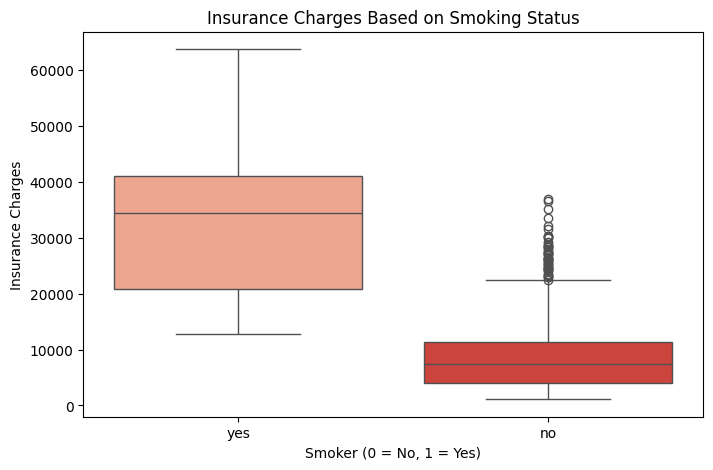

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['smoker'], y=df['charges'], palette="Reds")
plt.xlabel("Smoker (0 = No, 1 = Yes)")
plt.ylabel("Insurance Charges")
plt.title("Insurance Charges Based on Smoking Status")
plt.show()

C:\Users\singh\AppData\Local\Temp\ipykernel_10296\359914929.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['children'], y=df['charges'], palette="Purples")


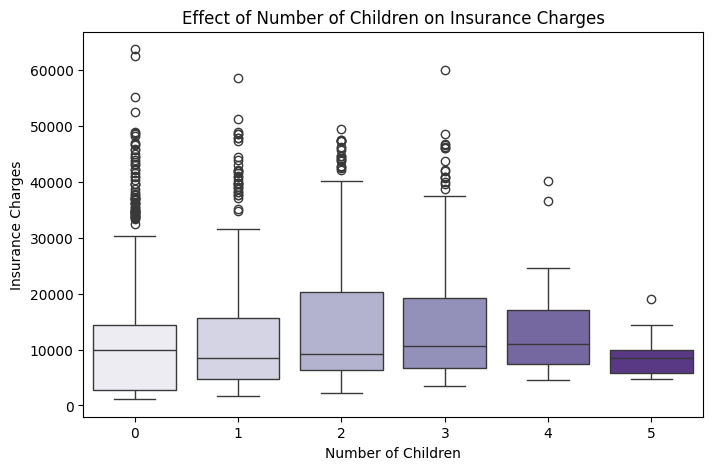

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['children'], y=df['charges'], palette="Purples")
plt.xlabel("Number of Children")
plt.ylabel("Insurance Charges")
plt.title("Effect of Number of Children on Insurance Charges")
plt.show()

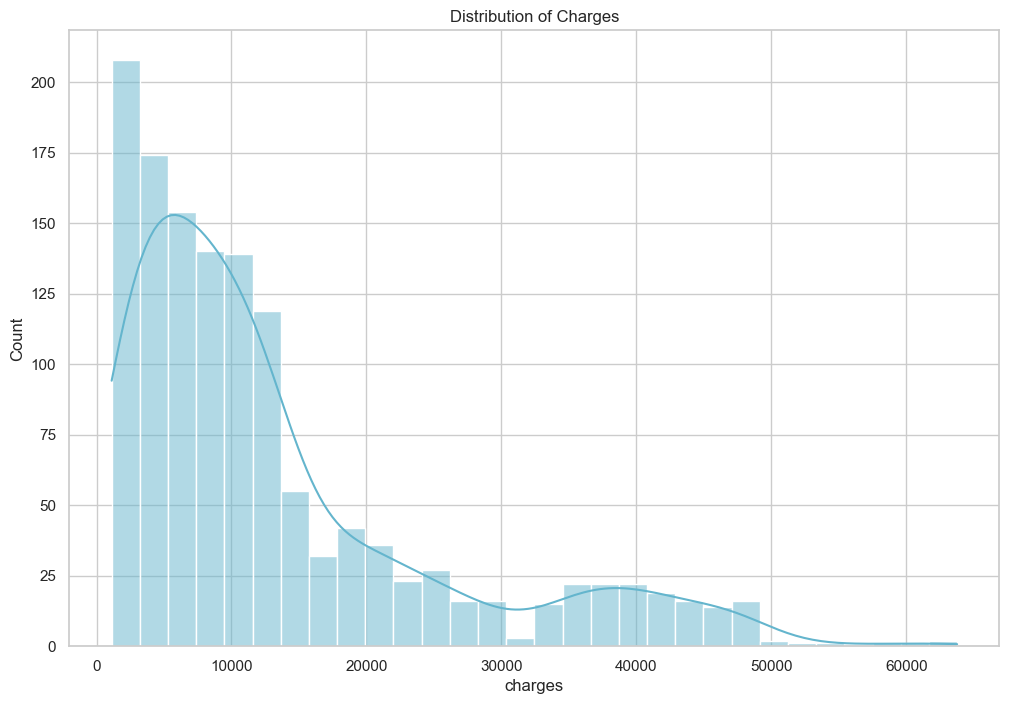

In [13]:
# Visualization: Distribution of insurance charges
sns.set(style='whitegrid')
plt.figure(figsize=(12, 8))
sns.histplot(df['charges'], kde=True, color='c')
plt.title('Distribution of Charges')
plt.show()

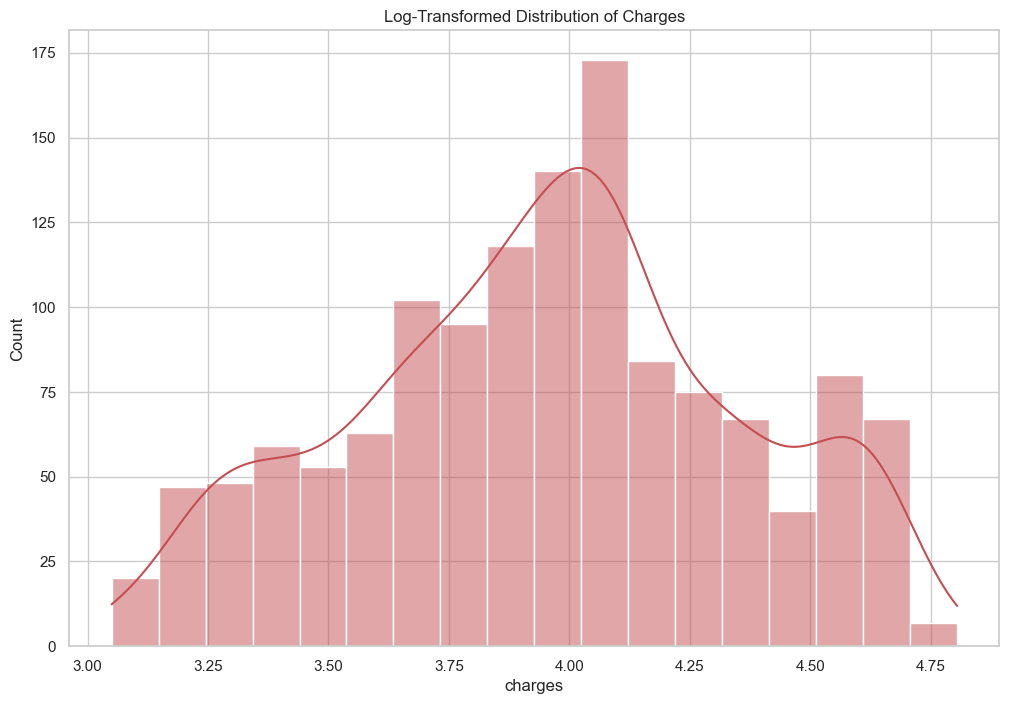

In [14]:
# Visualizing log-transformed charges to see normality
plt.figure(figsize=(12, 8))
sns.histplot(np.log10(df['charges']), kde=True, color='r')
plt.title('Log-Transformed Distribution of Charges')
plt.show()

C:\Users\singh\AppData\Local\Temp\ipykernel_10296\381193830.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=charges_by_region.values, y=charges_by_region.index, palette="Blues")


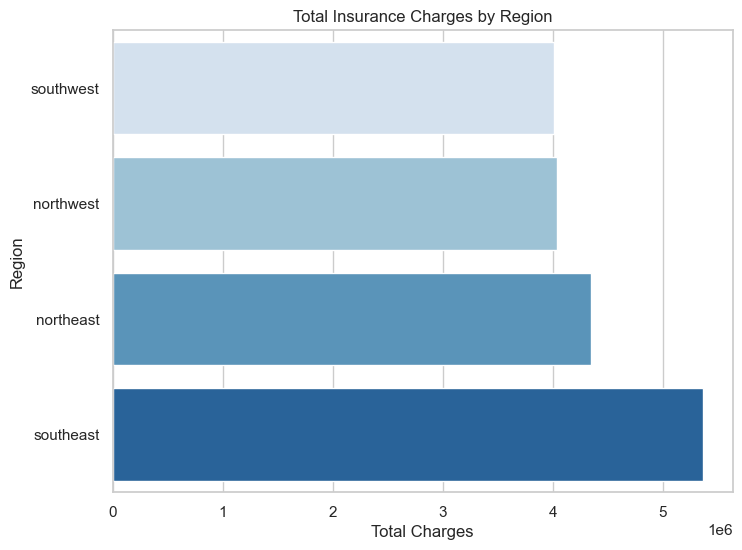

In [15]:
# Bar plot of total insurance charges by region
charges_by_region = df.groupby("region")["charges"].sum().sort_values(ascending=True)
plt.figure(figsize=(8, 6))
sns.barplot(x=charges_by_region.values, y=charges_by_region.index, palette="Blues")
plt.xlabel("Total Charges")
plt.ylabel("Region")
plt.title("Total Insurance Charges by Region")
plt.show()

In [16]:
# Encoding categorical variables
df[['sex', 'smoker', 'region']] = df[['sex', 'smoker', 'region']].astype('category')

In [17]:
# Convert categorical labels into numerical format using LabelEncoder
label_encoder = LabelEncoder()
df['sex'] = label_encoder.fit_transform(df['sex'])
df['smoker'] = label_encoder.fit_transform(df['smoker'])
df['region'] = label_encoder.fit_transform(df['region'])

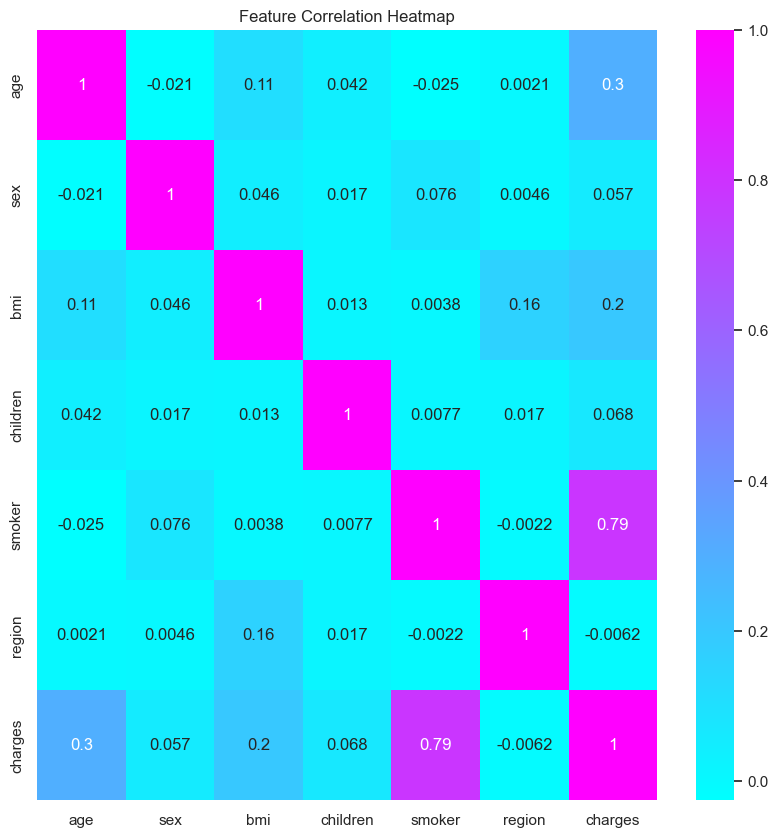

In [18]:
# Heatmap to check feature correlations
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True, cmap='cool')
plt.title("Feature Correlation Heatmap")
plt.show()

In [19]:
# Splitting dataset into training and testing sets
X = df.drop(columns=['charges'])
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Model 1 - Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)  # Train the model

LinearRegression()

In [21]:
# Predictions
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

In [22]:
y_test_pred_lin = lin_reg.predict(X_test)
r2_lin = r2_score(y_test, y_test_pred_lin)
mae_lin = mean_absolute_error(y_test, y_test_pred_lin)
mse_lin = mean_squared_error(y_test, y_test_pred_lin)

print(f"Linear Regression: R² = {r2_lin}, MAE = {mae_lin}, MSE = {mse_lin}")

Linear Regression: R² = 0.7833463107364539, MAE = 4186.508898366432, MSE = 33635210.431178406


In [23]:
# Model 2 - Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, criterion="squared_error", random_state=1, n_jobs=-1)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=1)

In [24]:
# Predictions
y_train_pred_rf = rf_reg.predict(X_train)
y_test_pred_rf = rf_reg.predict(X_test)

In [25]:
y_test_pred_rf = rf_reg.predict(X_test)
r2_rf = r2_score(y_test, y_test_pred_rf)
mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
mse_rf = mean_squared_error(y_test, y_test_pred_rf)

print(f"Random Forest: R² = {r2_rf}, MAE = {mae_rf}, MSE = {mse_rf}")


Random Forest: R² = 0.865751377474235, MAE = 2461.452011240953, MSE = 20841928.351642944


In [26]:
# Model 3 - Polynomial Regression
poly = PolynomialFeatures(degree=2)  # Creating polynomial features
X_poly = poly.fit_transform(X)  # Transforming X into polynomial form

In [27]:
# Splitting the transformed dataset
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

In [28]:
# Training polynomial regression model
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

LinearRegression()

In [29]:
# Predictions
y_test_pred_poly = poly_reg.predict(X_test_poly)
r2_poly = r2_score(y_test, y_test_pred_poly)
mae_poly = mean_absolute_error(y_test, y_test_pred_poly)
mse_poly = mean_squared_error(y_test, y_test_pred_poly)

print(f"Polynomial Regression: R² = {r2_poly}, MAE = {mae_poly}, MSE = {mse_poly}")


Polynomial Regression: R² = 0.8677566718537749, MAE = 2730.315581680445, MSE = 20530608.942951787


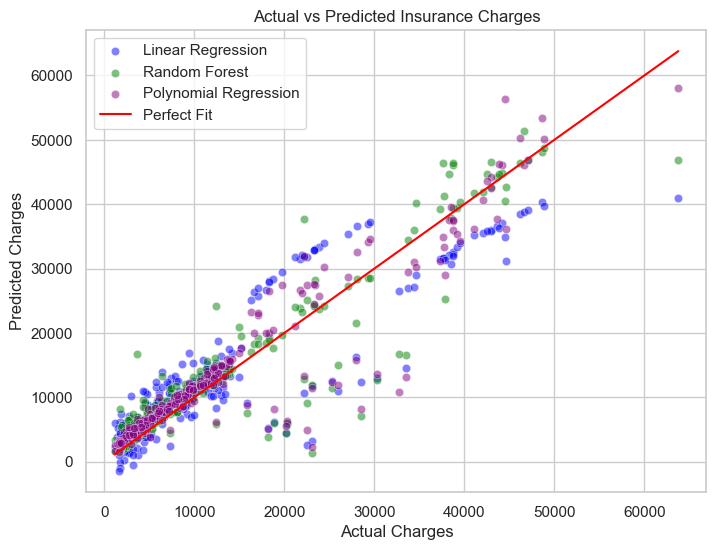

In [30]:
# Visualization of Actual vs. Predicted Charges
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5, label="Linear Regression", color="blue")
sns.scatterplot(x=y_test, y=y_test_pred_rf, alpha=0.5, label="Random Forest", color="green")
sns.scatterplot(x=y_test, y=y_test_pred_poly, alpha=0.5, label="Polynomial Regression", color="purple")
sns.lineplot(x=y_test, y=y_test, color="red", label="Perfect Fit")  # 45-degree line

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.show()


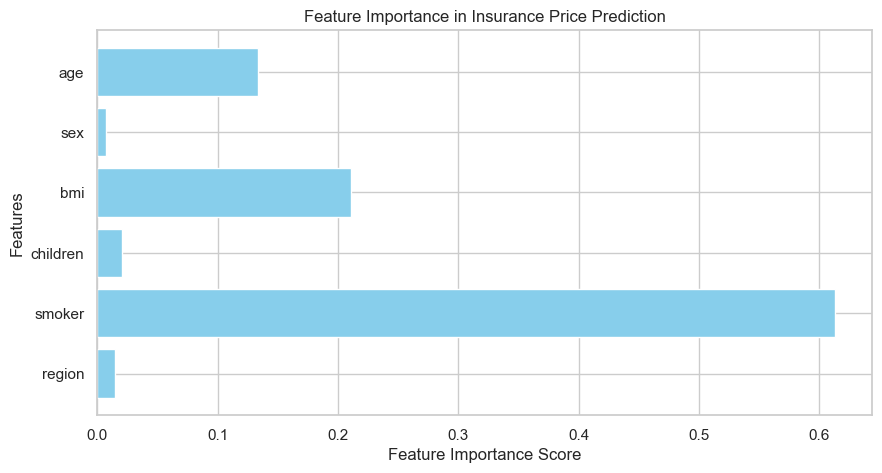

In [31]:
# Feature Importance Plot
feature_importances = rf_reg.feature_importances_
features = X.columns

plt.figure(figsize=(10, 5))
plt.barh(features, feature_importances, color='skyblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Insurance Price Prediction")
plt.gca().invert_yaxis()  # Invert to show highest importance at the top
plt.show()